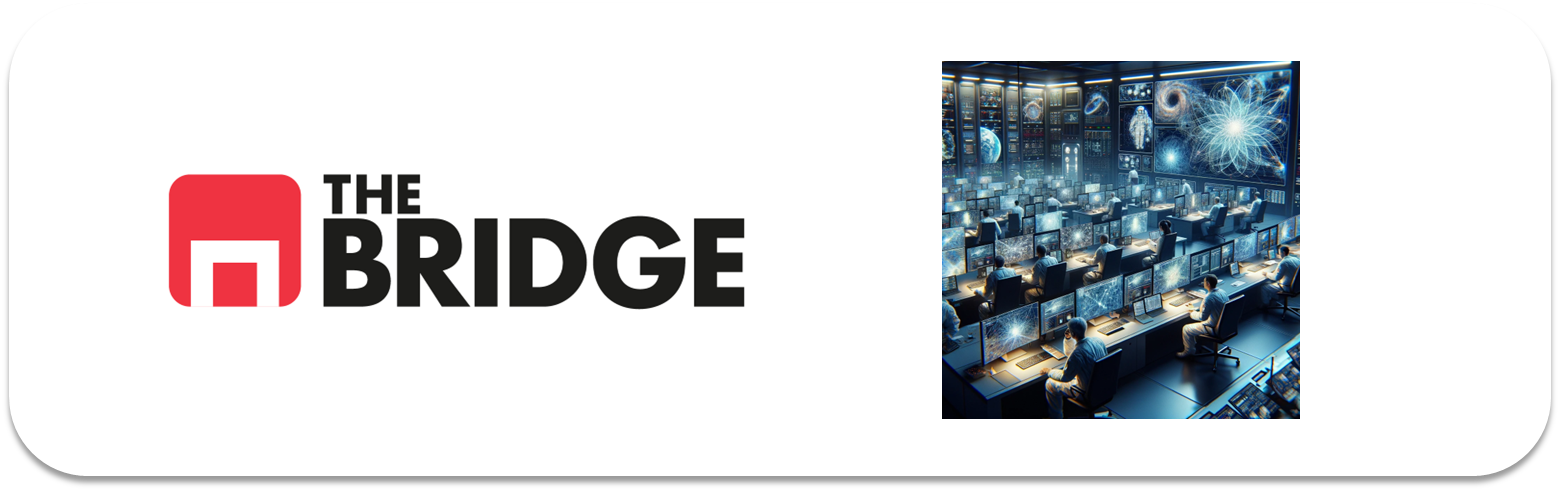

## PRACTICA OBLIGATORIA: **Transfer Learning y Fine Tuning con CNN**

* La práctica obligatoria de esta unidad consiste en un repetir el ejercicio de construcción de un modelo de clasificación de paisajes pero usando un modelo preentrenado. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

np.random.seed(42)
tf.random.set_seed(42)

IMG_SIZE = (96, 96)

import warnings
warnings.filterwarnings('ignore')

### Objetivo del ejercicio

Comparar una red convolucional hecha ad-hoc frente a los modelos preentrenados y ajustados con fine tuning y transfer learning. Para ello emplea el dataset de paisajes del conjunto de ejercicios de la unidad anterior.


### Se pide

1. Preparar los datos del modelo y las funciones de visualización, copia para ello todo lo que necesites de las soluciones del ejercicio de clasificación de paisajes de la unidad anterior.

2. Escoger entre uno de los modelos VGG-19, InceptionV3 y MobileNetV2 (todos en https://keras.io/api/applications/) (Se aconseja este último si no tenemos un ordenador muy potente). Si no te haces con estos puedes recurrir a la ResNetV50.

4. Hacer un transfer-learning con una cabeza de como mucho 2 capas densas ocultas y una de salida. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

5. Hacer un fine-tuning con la misma cabeza diseñada en el punto anterior. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

6. Comparar los resultados con los obtenidos con la red convolucional del ejercicio mencionado.

EXTRA:
- Repetir el transfer learning empleando aumentado de imágenes.



### Ejercicio 1

Preparación de los datos (reutilizando la lógica de carga de la práctica anterior de CNN, adaptada al dataset de gatos y perros) y funciones de visualización.

Train -> (4000, 96, 96, 3) (4000,)
Test  -> (1000, 96, 96, 3) (1000,)


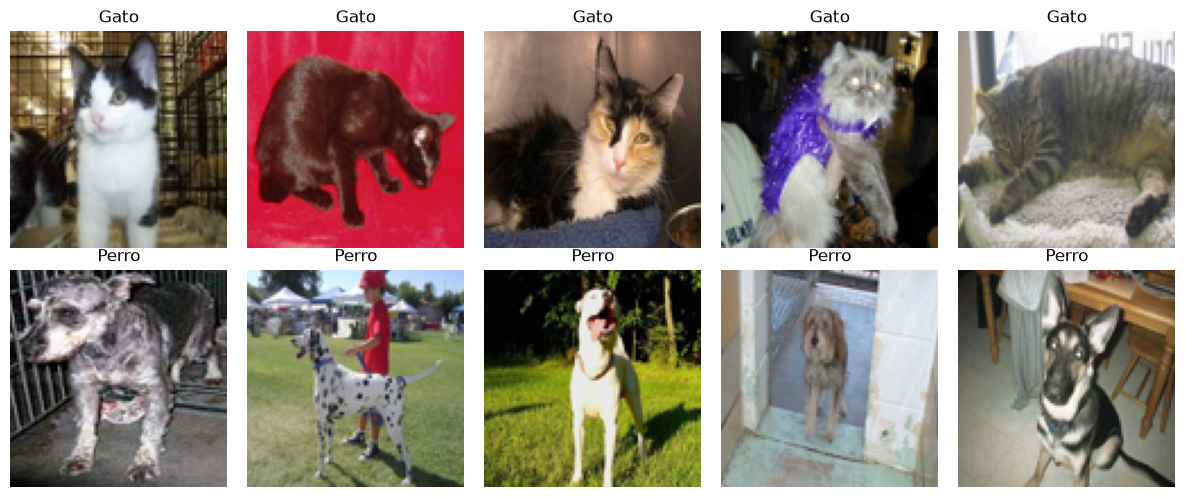

In [2]:
def obtener_label(nombre_fichero):
    """Extrae la etiqueta (0=gato, 1=perro) a partir del nombre del archivo."""
    nombre = nombre_fichero.lower()
    if "cat" in nombre:
        return 0
    elif "dog" in nombre:
        return 1
    else:
        return None


def cargar_imagenes_de_directorio(directorio, size=IMG_SIZE):
    X, y, filenames = [], [], []
    for fname in sorted(os.listdir(directorio)):
        fpath = os.path.join(directorio, fname)
        if not os.path.isfile(fpath):
            continue
        label = obtener_label(fname)
        if label is None:
            continue
        try:
            img = Image.open(fpath).convert("RGB").resize(size)
        except Exception as e:
            print(f"No se pudo leer {fpath}: {e}")
            continue
        X.append(np.array(img))
        y.append(label)
        filenames.append(fname)
    return np.array(X), np.array(y), filenames


def cargar_dataset(directorios, size=IMG_SIZE):
    X_total, y_total, files_total = [], [], []
    for d in directorios:
        Xd, yd, filesd = cargar_imagenes_de_directorio(d, size=size)
        X_total.append(Xd)
        y_total.append(yd)
        files_total.extend(filesd)
    X_total = np.concatenate(X_total, axis=0)
    y_total = np.concatenate(y_total, axis=0)
    return X_total, y_total, files_total


train_dirs = [
    os.path.join("data/github_train_0"),
    os.path.join("data/github_train_1"),
    os.path.join("data/github_train_2"),
    os.path.join("data/github_train_3"),
]
test_dir = os.path.join("data/github_test")

X_train, y_train, files_train = cargar_dataset(train_dirs)
X_test, y_test, files_test = cargar_dataset([test_dir])

print("Train ->", X_train.shape, y_train.shape)
print("Test  ->", X_test.shape, y_test.shape)

clases = {0: "Gato", 1: "Perro"}
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for clase in [0, 1]:
    idxs = np.where(y_train == clase)[0][:5]
    for j, idx in enumerate(idxs):
        axes[clase, j].imshow(X_train[idx])
        axes[clase, j].set_title(clases[clase])
        axes[clase, j].axis("off")
plt.tight_layout()
plt.show()


In [3]:
# Split train/val, y preprocesado específico de MobileNetV2 (importante: no dividir entre 255 manualmente,
# preprocess_input ya hace el escalado que espera la red preentrenada)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

X_tr_prep = preprocess_input(X_tr.astype("float32"))
X_val_prep = preprocess_input(X_val.astype("float32"))
X_test_prep = preprocess_input(X_test.astype("float32"))

print("Train:", X_tr_prep.shape, "Val:", X_val_prep.shape, "Test:", X_test_prep.shape)


Train: (3200, 96, 96, 3) Val: (800, 96, 96, 3) Test: (1000, 96, 96, 3)


### Ejercicio 2

Elegimos **MobileNetV2** preentrenada en ImageNet (recomendada para equipos sin GPU potente), sin la parte superior (`include_top=False`), como extractor de características.

In [4]:
base_model = MobileNetV2(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False  # Congelamos el modelo base para el transfer learning

base_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "mobilenetv2_1.00_96"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

### Ejercicio 3 (parte 1): Transfer Learning

Añadimos una cabeza de como mucho 2 capas densas ocultas + 1 capa de salida, y entrenamos solo la cabeza (el resto de la red permanece congelado).

In [5]:
def construir_cabeza(base_model):
    inputs = Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.3)(x)
    x = Dense(64, activation="relu")(x)
    outputs = Dense(1, activation="sigmoid")(x)
    return Model(inputs, outputs)


model_tl = construir_cabeza(base_model)
model_tl.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model_tl.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,430,273 (9.27 MB)

 Trainable params: 172,289 (673.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [6]:
early_stop_tl = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)

history_tl = model_tl.fit(
    X_tr_prep, y_tr,
    validation_data=(X_val_prep, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop_tl],
    verbose=1,
)

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 95ms/step - accuracy: 0.9306 - loss: 0.1666 - val_accuracy: 0.9463 - val_loss: 0.1402
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 75ms/step - accuracy: 0.9709 - loss: 0.0828 - val_accuracy: 0.9488 - val_loss: 0.1289
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.9834 - loss: 0.0530 - val_accuracy: 0.9538 - val_loss: 0.1271
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.9897 - loss: 0.0316 - val_accuracy: 0.9588 - val_loss: 0.1286
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step - accuracy: 0.9925 - loss: 0.0235 - val_accuracy: 0.9575 - val_loss: 0.1511
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 67ms/step - accuracy: 0.9937 - loss: 0.0152 - val_accuracy: 0.9588 - val_loss: 0.1556
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.9978 - loss: 0.0091 - val_accuracy: 0.9625 - val_loss: 0.1806
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - accuracy: 0.9984 - loss: 0.0049 - val_acc

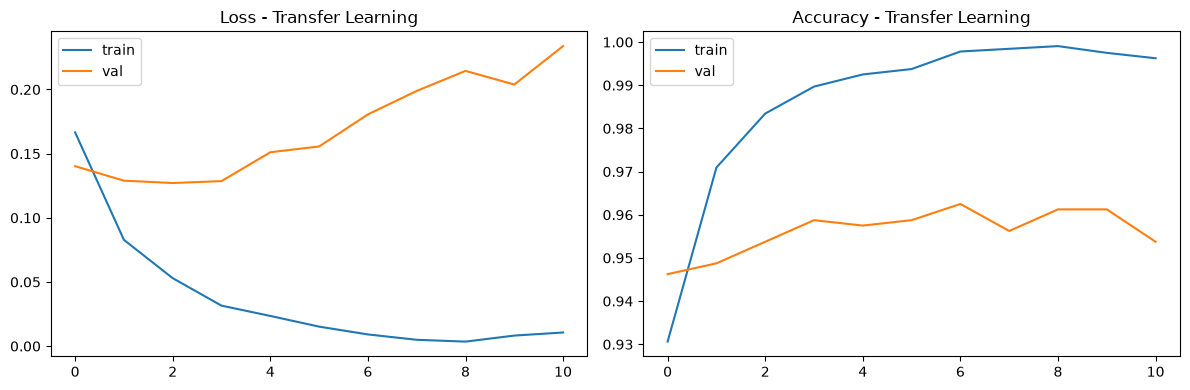

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_tl.history["loss"], label="train")
axes[0].plot(history_tl.history["val_loss"], label="val")
axes[0].set_title("Loss - Transfer Learning")
axes[0].legend()

axes[1].plot(history_tl.history["accuracy"], label="train")
axes[1].plot(history_tl.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy - Transfer Learning")
axes[1].legend()
plt.tight_layout()
plt.show()

[Transfer Learning] Test loss: 0.1173 - Test accuracy: 0.9570

Reporte de clasificación (Transfer Learning):

              precision    recall  f1-score   support

        Gato       0.96      0.96      0.96       500
       Perro       0.96      0.96      0.96       500

    accuracy                           0.96      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.96      0.96      0.96      1000



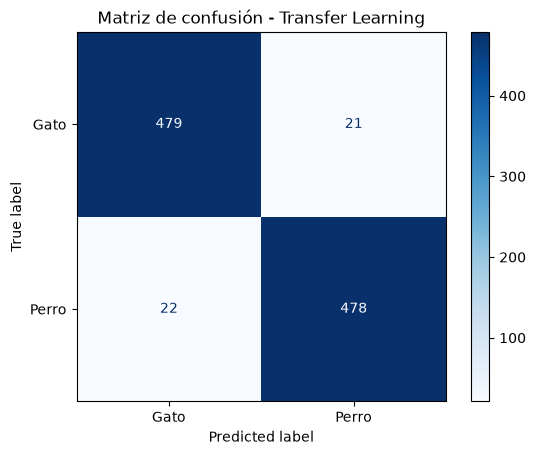

In [8]:
test_loss_tl, test_acc_tl = model_tl.evaluate(X_test_prep, y_test, verbose=0)
print(f"[Transfer Learning] Test loss: {test_loss_tl:.4f} - Test accuracy: {test_acc_tl:.4f}")

y_proba_tl = model_tl.predict(X_test_prep, verbose=0).ravel()
y_pred_tl = (y_proba_tl >= 0.5).astype(int)

print("\nReporte de clasificación (Transfer Learning):\n")
print(classification_report(y_test, y_pred_tl, target_names=["Gato", "Perro"]))

cm_tl = confusion_matrix(y_test, y_pred_tl)
ConfusionMatrixDisplay(confusion_matrix=cm_tl, display_labels=["Gato", "Perro"]).plot(cmap="Blues")
plt.title("Matriz de confusión - Transfer Learning")
plt.show()

### Ejercicio 3 (parte 2): Fine Tuning

Descongelamos las últimas capas de la base preentrenada y continuamos el entrenamiento con una tasa de aprendizaje baja, manteniendo la misma cabeza.

In [9]:
# Descongelamos el modelo base, pero mantenemos congeladas las primeras capas
# (las más genéricas) y solo entrenamos las últimas, más específicas.
base_model.trainable = True

fine_tune_at = len(base_model.layers) - 30  # últimas 30 capas entrenables
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # LR mucho más baja para no destruir los pesos preentrenados
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
model_tl.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,430,273 (9.27 MB)

 Trainable params: 1,698,689 (6.48 MB)

 Non-trainable params: 731,584 (2.79 MB)

In [10]:
early_stop_ft = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)

history_ft = model_tl.fit(
    X_tr_prep, y_tr,
    validation_data=(X_val_prep, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop_ft],
    verbose=1,
)

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 106ms/step - accuracy: 0.8875 - loss: 0.3052 - val_accuracy: 0.9563 - val_loss: 0.1436
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - accuracy: 0.9556 - loss: 0.1189 - val_accuracy: 0.9600 - val_loss: 0.1398
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - accuracy: 0.9759 - loss: 0.0832 - val_accuracy: 0.9600 - val_loss: 0.1352
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - accuracy: 0.9841 - loss: 0.0573 - val_accuracy: 0.9625 - val_loss: 0.1303
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - accuracy: 0.9897 - loss: 0.0413 - val_accuracy: 0.9663 - val_loss: 0.1290
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - accuracy: 0.9947 - loss: 0.0323 - val_accuracy: 0.9675 - val_loss: 0.1282
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - accuracy: 0.9950 - loss: 0.0249 - val_accuracy: 0.9688 - val_loss: 0.1291
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.9987 - loss: 0.0191 - val_

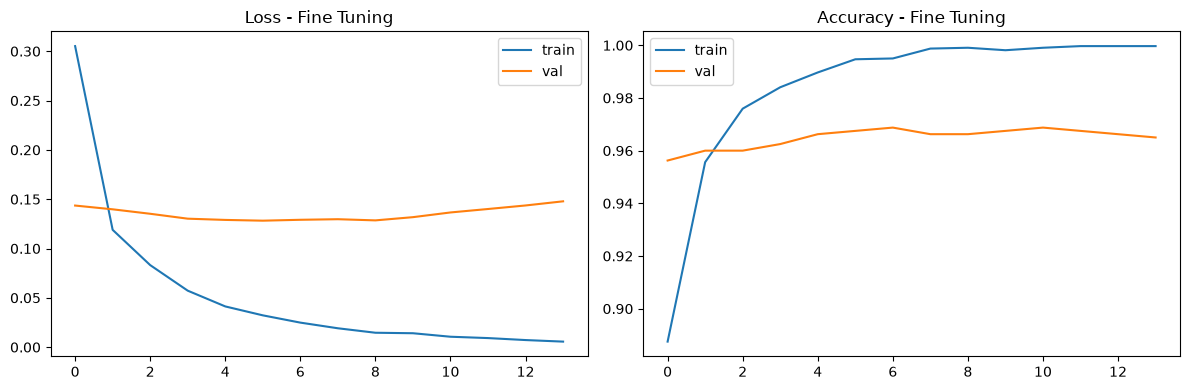

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_ft.history["loss"], label="train")
axes[0].plot(history_ft.history["val_loss"], label="val")
axes[0].set_title("Loss - Fine Tuning")
axes[0].legend()

axes[1].plot(history_ft.history["accuracy"], label="train")
axes[1].plot(history_ft.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy - Fine Tuning")
axes[1].legend()
plt.tight_layout()
plt.show()

[Fine Tuning] Test loss: 0.1138 - Test accuracy: 0.9630

Reporte de clasificación (Fine Tuning):

              precision    recall  f1-score   support

        Gato       0.95      0.97      0.96       500
       Perro       0.97      0.95      0.96       500

    accuracy                           0.96      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.96      0.96      0.96      1000



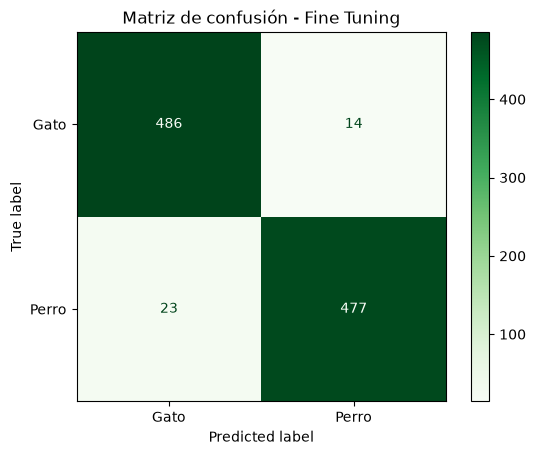

In [12]:
test_loss_ft, test_acc_ft = model_tl.evaluate(X_test_prep, y_test, verbose=0)
print(f"[Fine Tuning] Test loss: {test_loss_ft:.4f} - Test accuracy: {test_acc_ft:.4f}")

y_proba_ft = model_tl.predict(X_test_prep, verbose=0).ravel()
y_pred_ft = (y_proba_ft >= 0.5).astype(int)

print("\nReporte de clasificación (Fine Tuning):\n")
print(classification_report(y_test, y_pred_ft, target_names=["Gato", "Perro"]))

cm_ft = confusion_matrix(y_test, y_pred_ft)
ConfusionMatrixDisplay(confusion_matrix=cm_ft, display_labels=["Gato", "Perro"]).plot(cmap="Greens")
plt.title("Matriz de confusión - Fine Tuning")
plt.show()

### Ejercicio 4

Comparación de resultados: CNN construida desde cero (práctica anterior) vs. Transfer Learning vs. Fine Tuning.

In [13]:
# Accuracy obtenida con la CNN entrenada desde cero en la práctica anterior
# (sustituye este valor por el que obtuviste al ejecutar aquel notebook).
test_acc_cnn_scratch = None  # p.ej. 0.75

resultados = pd.DataFrame({
    "Modelo": ["CNN desde cero", "Transfer Learning (MobileNetV2)", "Fine Tuning (MobileNetV2)"],
    "Test accuracy": [test_acc_cnn_scratch, test_acc_tl, test_acc_ft],
})
resultados

,Modelo,Test accuracy
0,CNN desde cero,NaN
1,Transfer Learning (MobileNetV2),0.957
2,Fine Tuning (MobileNetV2),0.963


In [14]:
if resultados["Test accuracy"].notna().all():
    resultados.plot(x="Modelo", y="Test accuracy", kind="bar", legend=False, title="Comparativa de accuracy en test")
    plt.ylabel("Accuracy")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()
else:
    print("Rellena 'test_acc_cnn_scratch' con el resultado de la práctica anterior para ver la comparativa.")


Rellena 'test_acc_cnn_scratch' con el resultado de la práctica anterior para ver la comparativa.
